# Многослойный перцептрон

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from pathlib import Path
import warnings
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from research_utils.learning import grid_search, iteration_learning_score, get_top_n_info
from research_utils.plot import create_panel, plot_learning_curve, plot_complexity_and_accuracy, df_hist, df_scatter, series_hist, series_scatter
from research_utils.stats import agg_by_columns
from predictors.serialization import save_model
from predictors.feature_selection import ModelFeatureSelector
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
def loss_curve(mlp, ax):
    epochs = range(1, len(mlp.loss_curve_) + 1)
    
    ax.plot(epochs, mlp.loss_curve_, 'b-', linewidth=2, label='Training Loss')
    
    if hasattr(mlp, 'validation_scores_'):
        plt.plot(mlp.validation_scores_, label='Validation accuracy', 
                linewidth=2, color='orange', linestyle='--')

    ax.set_title('Кривая запоминания обучающей выборки\n(Training Loss Curve)', fontsize=14)
    ax.set_xlabel('Эпоха обучения', fontsize=12)
    ax.set_ylabel('Функция потерь (Loss)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()

In [2]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

save = partial(save_model, models_dir)
train = pd.read_parquet("../data/processed/train.parquet")

## Подготовка данных
Многослойный перцептрон:
- Чувствителен к выбросам.
- Требует приведение признаков к единому масштабу
- Лучше работает при нормальном распределении

Мультиколлинеарные признаки можно оставить, отбор признаков можно не производить

In [3]:
numeric_features = {
    'text__symbols_length',
    'text__sentences_count',
    'text__long_sentences_proportion',
    'text__unpopular_words_proportion',
    'text__rare_words_proportion',
    'text__type_token_ratio',
    'text__normalized_shannon_entropy',
    'text__mean_words_length',
    'text__long_words_proportion',
    'text__lexicon_size',
    'text__lexical_diversity_per_sentence',
    'entities__breadth_of_use_entities',
    'pos__index_of_formality',
    'pos__mean_usage_NOUN',
    'pos__mean_usage_PRON',
    'pos__mean_usage_ADV',
    'pos__mean_usage_ADP',
    'pos__mean_usage_ADJ',
    'pos__mean_usage_SCONJ',
    'pos__mean_usage_CCONJ',
    'pos__mean_usage_VERB',
    'pos__mean_usage_PROPN',
    'pos__mean_usage_DET',
    'pos__mean_usage_PART',
    'pos__ADJPOS_NOUN',
    'pos__PUNCT_SCONJ',
    'pos__ADP_ADJPOS',
    'pos__ADP_PRON',
    'pos__PUNCT_ADV',
    'pos__ADJPOS_PUNCT',
    'pos__PUNCT_CCONJ',
    'pos__index_of_formality_heylinger',
    'punct__breadth_of_use_puncts',
    'punct__mean_usage_comma',
}
combo_features = { 
    "pos__pair_of_adv_per_sentence",
    "pos__mean_usage_AUX",
    "pos__mean_usage_NUM",
    "pos__PROPN_PUNCT",
    "pos__PUNCT_PRON",
    "punct__mean_usage_colon",
    "punct__mean_usage_question",
    "punct__mean_usage_openparen",
    "punct__mean_usage_closeparen",
    "punct__mean_usage_hyphen",
    "punct__mean_usage_exclamation",
    "entities__mean_usage_NUMBER",
    "entities__mean_usage_QUOTE",
    "entities__mean_usage_PUNCEM",
    "entities__mean_usage_ADDRESS",
}
combo_flags = { f"{col}_used" for col in combo_features }
typical_features = {
    'entities__mean_usage_MEAS_is_typical',
    'entities__mean_usage_ENUM_is_typical',
    'entities__mean_usage_FOREIGN_is_typical',
    'pos__breadth_of_use_pos_is_typical',
    'pos__index_of_formality_tuldava_is_typical',
    'entities__mean_usage_SMILE_is_typical',
    'entities__mean_usage_DATE_is_typical'
}
features = numeric_features | combo_features | combo_flags | typical_features
features_list = list(features)

In [ ]:
numeric_fix_list = list(numeric_features.difference([
    "punct__breadth_of_use_puncts",
    "entities__breadth_of_use_entities",
    "pos__index_of_formality_heylinger",
    "text__type_token_ratio"
]))
combo_fix_list = list(combo_features)

def create_mlp_pipeline(model_params=None):
    if not model_params:
        model_params = {}
    
    return Pipeline([
        ('get_features', ModelFeatureSelector(features_list)),
        
        ('power_transform', ColumnTransformer([
            ('numeric_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in numeric_fix_list]),
            ('combo_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in combo_fix_list]),
        ], remainder='passthrough')),
        
        ('preprocessing', ColumnTransformer([
            ('numeric', RobustScaler(), [features_list.index(f) for f in numeric_features]),
            ('combo_intensive', RobustScaler(), [features_list.index(f) for f in combo_features]),
        ], remainder='passthrough')),
        
        ('model', MLPClassifier(**model_params))
    ])

## Поиск переобучаемой конфигурации

Проверим способность модели запомнить весь датасет. Точность такой модели должна составить около 1 на обучающей выборке и околонулевые значения функции потерь

In [ ]:
overhead_one_layer_gender_pipeline = create_mlp_pipeline({
    "hidden_layer_sizes": (256),
    "random_state": 42 ,
    "alpha": 0.0,
    "validation_fraction": 0.2,
    "verbose": True,
    "max_iter": 1000,
    "early_stopping": False,
    "batch_size": 128
})
overhead_one_layer_gender_pipeline.fit(train, train['gender'])

In [ ]:
train_accuracy = overhead_one_layer_gender_pipeline.score(train, train['gender'])
train_accuracy

0.9732987012987013

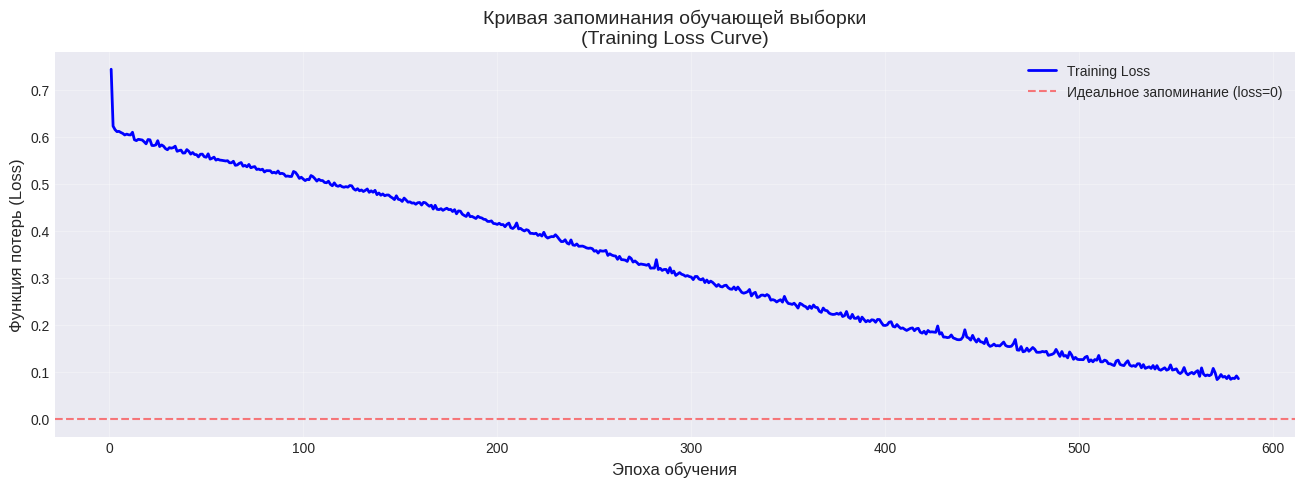

In [ ]:
fig, axes = create_panel(1, cols=1)
loss_curve(overhead_one_layer_gender_pipeline['model'], axes.flat[0])

Однослойная модель способна запомнить данные при кол-ве нейронов 256 и больше

In [ ]:
overhead_two_layer_gender_pipeline = create_mlp_pipeline({
    "hidden_layer_sizes": (128, 64),
    "random_state": 42 ,
    "alpha": 0.0,
    "validation_fraction": 0.2,
    "verbose": True,
    "max_iter": 1000,
    "early_stopping": False,
    "batch_size": 128
})
overhead_two_layer_gender_pipeline.fit(train, train['gender'])

In [ ]:
train_accuracy = overhead_two_layer_gender_pipeline.score(train, train['gender'])
train_accuracy

0.9846233766233766

Двуслойная модель способна запомнить данные при слоях нейронов (128, 64)

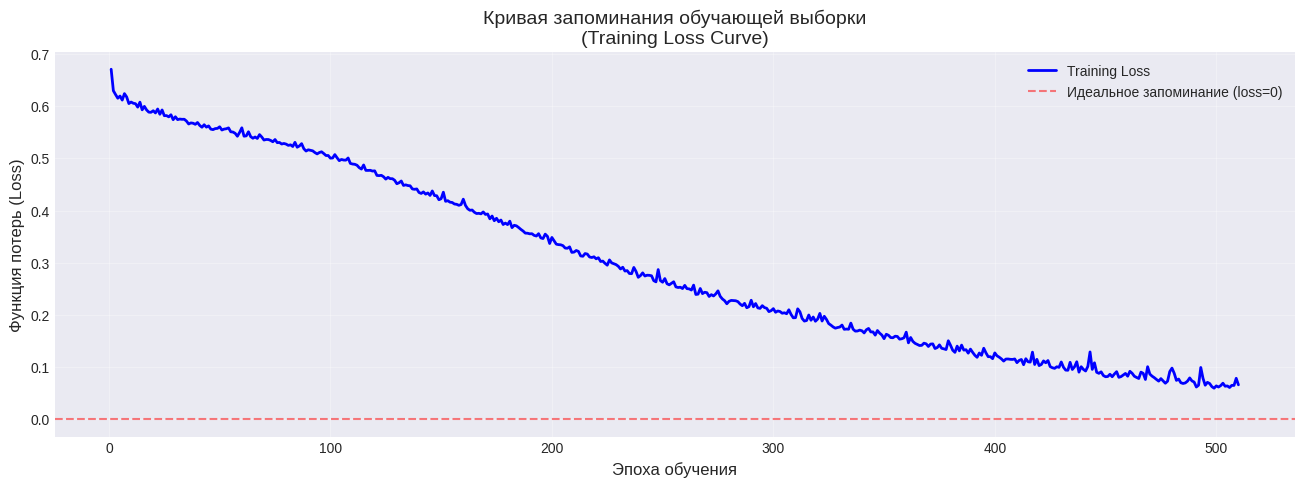

In [ ]:
fig, axes = create_panel(1, cols=1)
loss_curve(overhead_two_layer_gender_pipeline['model'], axes.flat[0])

На основании полученных результатов определим сетку гипперпараметров

In [49]:
hidden_layer_sizes = [ (198,), (128), (96), (64), (48), (32), (16), (96, 64), (64, 32), (32, 16), (16, 8) ]
activations = ['relu' ]
solvers= ['adam']
alphas= [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.15 ]  
learning_rate_inits= [ 0.000001, 0.000005, 0.00001, 0.00002, 0.00005, 0.0001  ] 

pipeline_params = {
    "model__hidden_layer_sizes": hidden_layer_sizes,
    "model__activation": activations,
    "model__solver": solvers,
    "model__alpha": alphas,
    "model__learning_rate_init": learning_rate_inits,
    "model__random_state": [ 42 ],
    "model__early_stopping": [ True ],
    "model__max_iter": [ 500 ],
    "model__validation_fraction": [ 0.2 ],
}

## Независимые модели

### Классификатор пола

In [50]:
gender_pipeline = create_mlp_pipeline()

gender_gs = grid_search(gender_pipeline, pipeline_params, train, train['gender'])

Fitting 5 folds for each of 462 candidates, totalling 2310 fits


In [51]:
gender_gs.best_params_, gender_gs.best_score_

({'model__activation': 'relu',
  'model__alpha': 0.15,
  'model__early_stopping': True,
  'model__hidden_layer_sizes': 128,
  'model__learning_rate_init': 0.0001,
  'model__max_iter': 500,
  'model__random_state': 42,
  'model__solver': 'adam',
  'model__validation_fraction': 0.2},
 np.float64(0.668987012987013))

In [55]:
gender_top_5_info = get_top_n_info(gender_gs, n=5)
gender_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__activation,param_model__alpha,param_model__early_stopping,param_model__hidden_layer_sizes,param_model__learning_rate_init,param_model__max_iter,...,param_model__validation_fraction,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
407,3.938958,0.457746,0.023860,0.001815,relu,0.1500,True,128,0.00010,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.678961,0.673766,0.651948,0.665455,0.674805,0.668987,0.009581,1
275,3.585439,0.450653,0.022607,0.001582,relu,0.0500,True,128,0.00010,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.676364,0.675325,0.651948,0.664416,0.670649,0.667740,0.008953,2
341,3.791719,0.462251,0.025870,0.004367,relu,0.1000,True,128,0.00010,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.676883,0.670130,0.651948,0.666494,0.670649,0.667221,0.008335,3
76,4.759375,0.813056,0.031535,0.002962,relu,0.0001,True,128,0.00005,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.672208,0.672208,0.652468,0.666494,0.669610,0.666597,0.007371,4
209,3.737160,0.243554,0.026132,0.003686,relu,0.0100,True,128,0.00010,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.668571,0.675325,0.649870,0.663896,0.674805,0.666494,0.009322,5


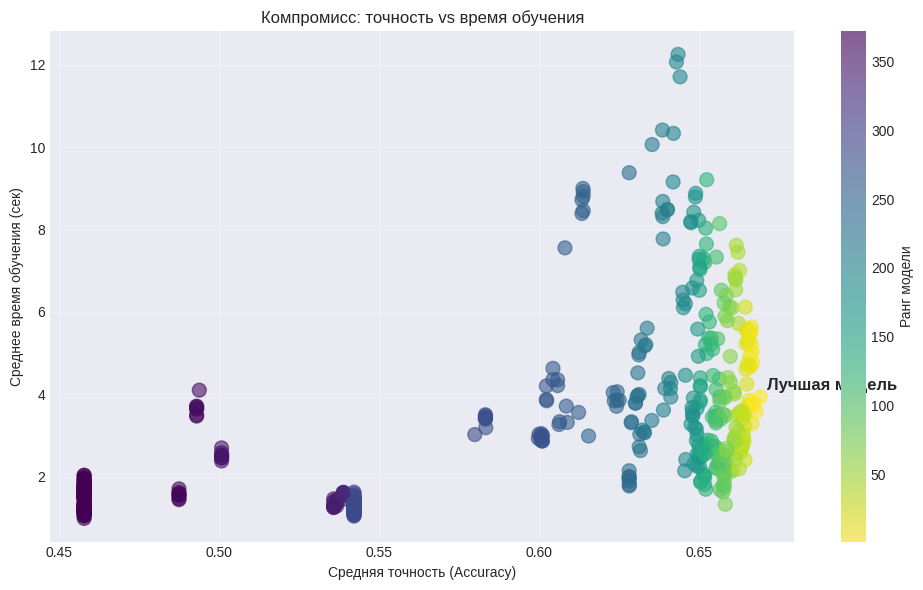

In [56]:
plot_complexity_and_accuracy(gender_gs)

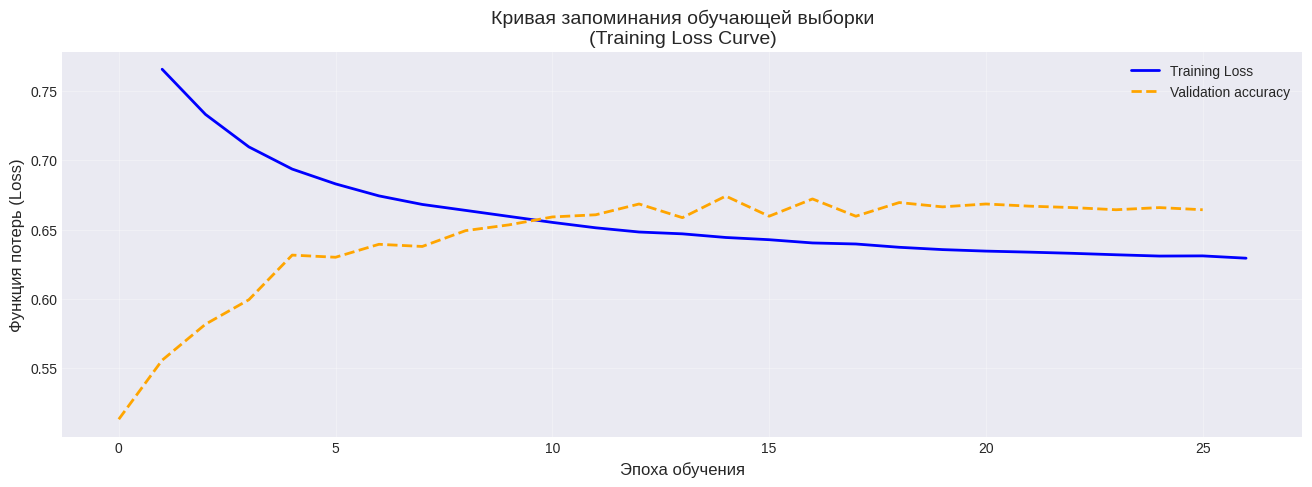

In [57]:
fig, axes = create_panel(1, cols=1)
loss_curve(gender_gs.best_estimator_['model'], axes.flat[0])

In [58]:
gender_best_model_params = {
  'model__activation': 'relu',
  'model__alpha': 0.15,
  'model__early_stopping': True,
  'model__hidden_layer_sizes': 128,
  'model__learning_rate_init': 0.0001,
  'model__max_iter': 500,
  'model__random_state': 42,
  'model__solver': 'adam',
  'model__validation_fraction': 0.2
}

gender_best_model = create_mlp_pipeline()
gender_best_model.set_params(**gender_best_model_params)
gender_best_model_iter_learning_score = iteration_learning_score(gender_best_model, train, train['gender'])

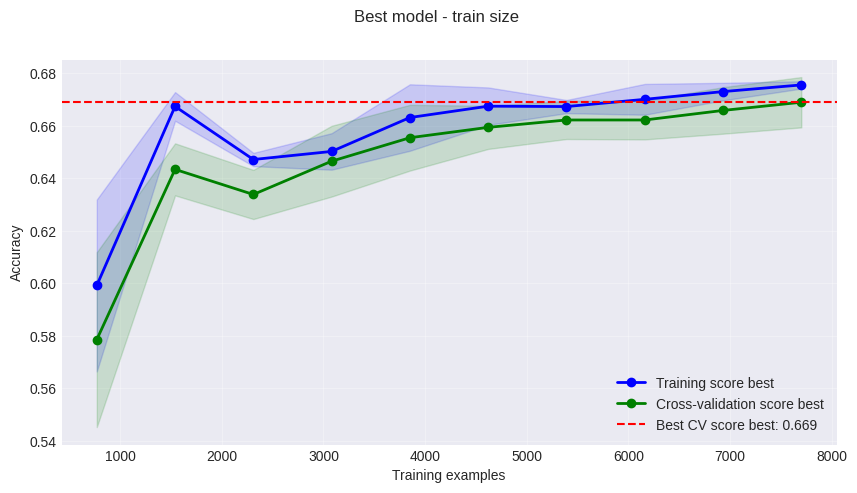

In [59]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*gender_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plt.suptitle("Best model - train size")
plt.show()

Лучший показатель - 66.9%

In [60]:
gender_best_model.fit(train, train['gender'])
save(
    gender_best_model, 
    "mlp_gender_best", 
    gender_best_model_params, 
    { "val": gender_best_model_iter_learning_score[2].tolist(), "train": gender_best_model_iter_learning_score[1].tolist() }
)

### Классификатор возраста

In [61]:
age_pipeline = create_mlp_pipeline()

age_gs = grid_search(age_pipeline, pipeline_params, train, train['age'])

Fitting 5 folds for each of 462 candidates, totalling 2310 fits


In [62]:
age_gs.best_params_, age_gs.best_score_

({'model__activation': 'relu',
  'model__alpha': 0.001,
  'model__early_stopping': True,
  'model__hidden_layer_sizes': (198,),
  'model__learning_rate_init': 0.0001,
  'model__max_iter': 500,
  'model__random_state': 42,
  'model__solver': 'adam',
  'model__validation_fraction': 0.2},
 np.float64(0.6187012987012988))

In [63]:
age_top_5_info = get_top_n_info(age_gs, n=5)
age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__activation,param_model__alpha,param_model__early_stopping,param_model__hidden_layer_sizes,param_model__learning_rate_init,param_model__max_iter,...,param_model__validation_fraction,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
137,6.002755,1.044217,0.035021,0.003063,relu,0.00100,True,"(198,)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.609870,0.624416,0.609351,0.622338,0.627532,0.618701,0.007606,1
401,7.170707,2.113673,0.036345,0.003180,relu,0.15000,True,"(198,)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.605195,0.621818,0.610390,0.627532,0.627532,0.618494,0.009132,2
203,5.019460,0.563802,0.036299,0.006414,relu,0.01000,True,"(198,)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.604675,0.622338,0.609870,0.621818,0.626494,0.617039,0.008301,3
269,5.011681,0.780508,0.036463,0.006160,relu,0.05000,True,"(198,)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.603117,0.622338,0.610390,0.622857,0.625974,0.616935,0.008715,4
5,5.976668,0.823226,0.035142,0.006221,relu,0.00001,True,"(198,)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.604675,0.614545,0.615584,0.617662,0.631169,0.616727,0.008494,5


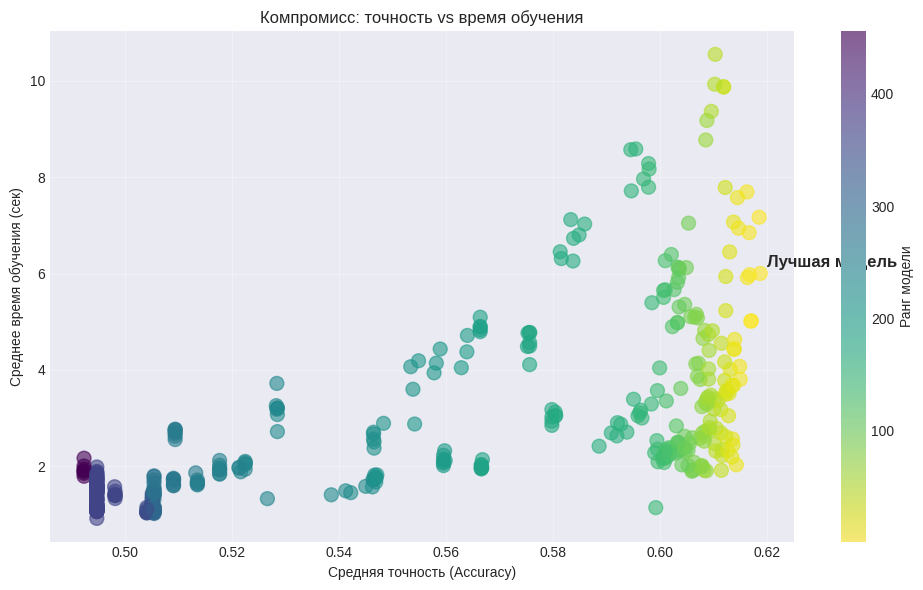

In [64]:
plot_complexity_and_accuracy(age_gs)

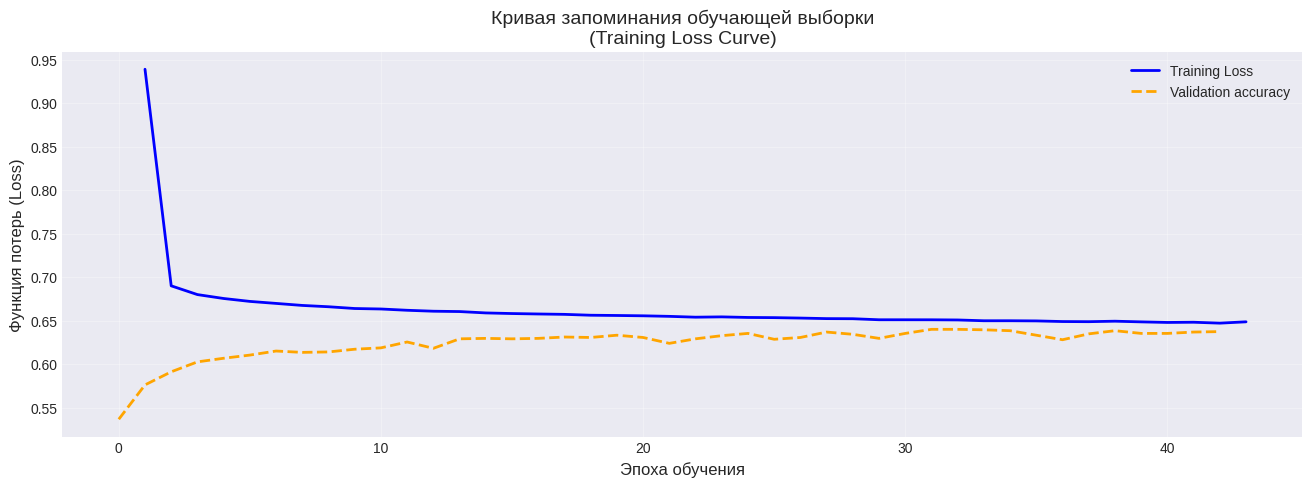

In [65]:
fig, axes = create_panel(1, cols=1)
loss_curve(age_gs.best_estimator_['model'], axes.flat[0])

In [66]:
age_best_model_params = {
  'model__activation': 'relu',
  'model__alpha': 0.001,
  'model__early_stopping': True,
  'model__hidden_layer_sizes': (198,),
  'model__learning_rate_init': 0.0001,
  'model__max_iter': 500,
  'model__random_state': 42,
  'model__solver': 'adam',
  'model__validation_fraction': 0.2
}

age_best_model = create_mlp_pipeline()
age_best_model.set_params(**age_best_model_params)
age_best_model_iter_learning_score = iteration_learning_score(age_best_model, train, train['age'])

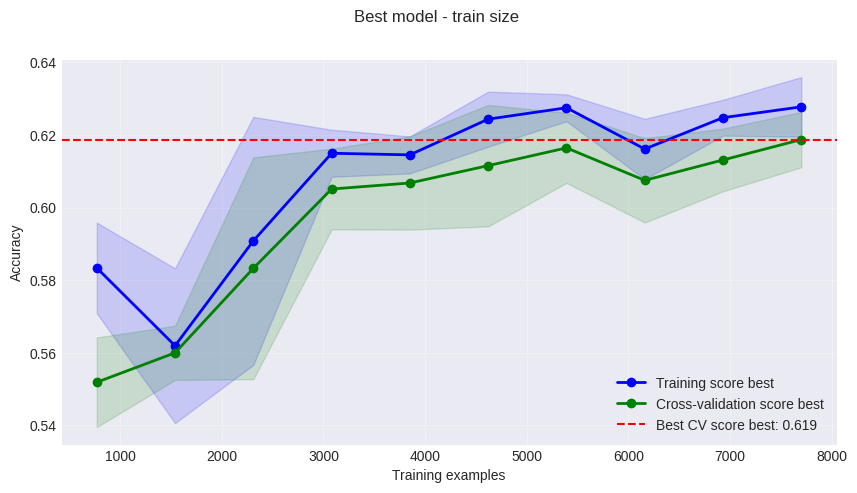

In [67]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plt.suptitle("Best model - train size")
plt.show()

Лучшая точность - 61.9%. 

In [68]:
age_best_model.fit(train, train['age'])
save(
    age_best_model, 
    "mlp_age_best", 
    age_best_model_params, 
    { "val": age_best_model_iter_learning_score[2].tolist(), "train": age_best_model_iter_learning_score[1].tolist() }
)

## Каскадный подход

Прогнозирование пола показывает более высокий показатель точности, по сравнению с прогнозирование возрастной группы. По этой причине сначала будет прогнозироваться пол, а затем в рамках пола - возраст

### Прогнозирование возраста мужчин

In [69]:
man_age_pipeline = create_mlp_pipeline()

men_train = train[train['gender'] == 1]

men_age_gs = grid_search(man_age_pipeline, pipeline_params, men_train, men_train['age'])

Fitting 5 folds for each of 462 candidates, totalling 2310 fits


In [70]:
men_age_gs.best_params_, men_age_gs.best_score_

({'model__activation': 'relu',
  'model__alpha': 0.001,
  'model__early_stopping': True,
  'model__hidden_layer_sizes': 64,
  'model__learning_rate_init': 0.0001,
  'model__max_iter': 500,
  'model__random_state': 42,
  'model__solver': 'adam',
  'model__validation_fraction': 0.2},
 np.float64(0.6330008853035929))

In [71]:
men_age_top_5_info = get_top_n_info(men_age_gs, n=5)
men_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__activation,param_model__alpha,param_model__early_stopping,param_model__hidden_layer_sizes,param_model__learning_rate_init,param_model__max_iter,...,param_model__validation_fraction,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
155,1.450859,0.093897,0.015558,0.001416,relu,0.00100,True,64,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.630268,0.640805,0.629310,0.628955,0.635666,0.633001,0.004593,1
221,1.418485,0.108813,0.014924,0.001235,relu,0.01000,True,64,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.630268,0.640805,0.625479,0.628955,0.637584,0.632618,0.005685,2
23,1.380418,0.094662,0.014442,0.001507,relu,0.00001,True,64,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.630268,0.640805,0.626437,0.628955,0.636625,0.632618,0.005296,3
89,1.479439,0.060087,0.015306,0.000862,relu,0.00010,True,64,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.630268,0.640805,0.625479,0.628955,0.636625,0.632426,0.005528,4
287,1.399029,0.105803,0.015571,0.002029,relu,0.05000,True,64,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.622605,0.640805,0.625479,0.627996,0.639501,0.631277,0.007456,5


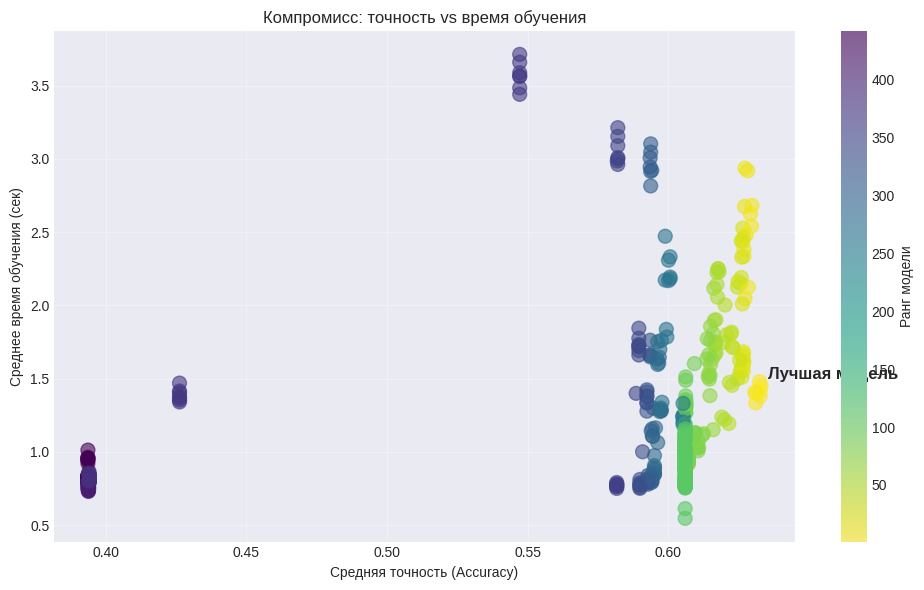

In [72]:
plot_complexity_and_accuracy(men_age_gs)

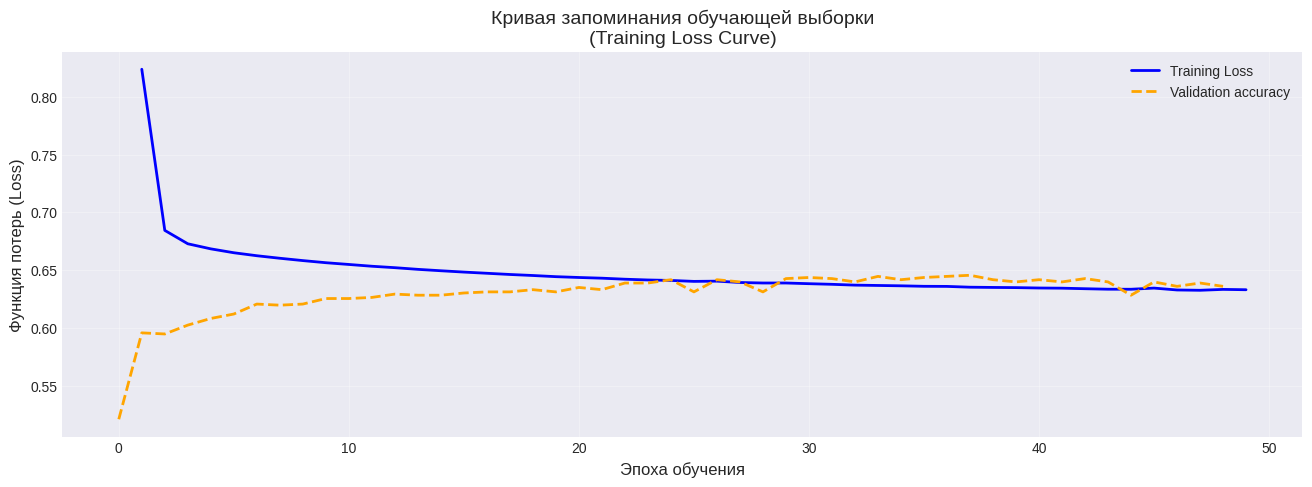

In [91]:
fig, axes = create_panel(1, cols=1)
loss_curve(men_age_gs.best_estimator_['model'], axes.flat[0])

In [73]:
men_age_best_model_params = {
    'model__activation': 'relu',
    'model__alpha': 0.001,
    'model__early_stopping': True,
    'model__hidden_layer_sizes': 64,
    'model__learning_rate_init': 0.0001,
    'model__max_iter': 500,
    'model__random_state': 42,
    'model__solver': 'adam',
    'model__validation_fraction': 0.2
}
men_age_best_model = create_mlp_pipeline()
men_age_best_model.set_params(**men_age_best_model_params)
men_age_best_model_iter_learning_score = iteration_learning_score(men_age_best_model, men_train, men_train['age'])

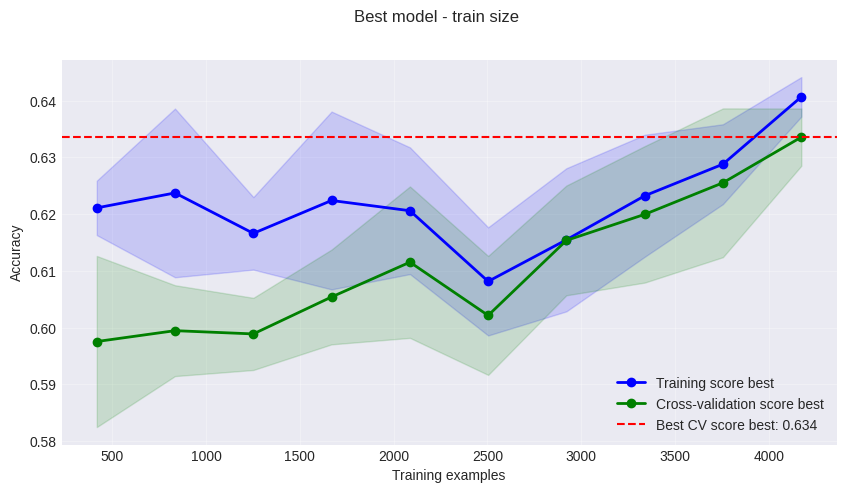

In [74]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*men_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plt.suptitle("Best model - train size")
plt.show()

Определение возраста в мужской подвыборке имеет точность на 1.5% выше, относительно общей модели (независимая). 

In [75]:
men_age_best_model.fit(men_train, men_train['age'])
save(
    men_age_best_model, 
    "mlp_men_age_best", 
    men_age_best_model_params, 
    { "val": men_age_best_model_iter_learning_score[2].tolist(), "train": men_age_best_model_iter_learning_score[1].tolist() }
)

### Прогнозирование возраста женщин

In [76]:
woman_age_pipeline = create_mlp_pipeline()

women_train = train[train['gender'] == 0]

women_age_gs = grid_search(woman_age_pipeline, pipeline_params, women_train, women_train['age'])

Fitting 5 folds for each of 462 candidates, totalling 2310 fits


In [77]:
women_age_gs.best_params_, women_age_gs.best_score_

({'model__activation': 'relu',
  'model__alpha': 1e-05,
  'model__early_stopping': True,
  'model__hidden_layer_sizes': (96, 64),
  'model__learning_rate_init': 0.0001,
  'model__max_iter': 500,
  'model__random_state': 42,
  'model__solver': 'adam',
  'model__validation_fraction': 0.2},
 np.float64(0.6605431881416963))

In [78]:
women_age_top_5_info = get_top_n_info(women_age_gs, n=5)
women_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__activation,param_model__alpha,param_model__early_stopping,param_model__hidden_layer_sizes,param_model__learning_rate_init,param_model__max_iter,...,param_model__validation_fraction,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
47,2.339236,0.321966,0.019913,0.003074,relu,0.00001,True,"(96, 64)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.647392,0.659864,0.669694,0.662883,0.662883,0.660543,0.007322,1
347,1.524266,0.140660,0.016258,0.003357,relu,0.10000,True,96,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.645125,0.648526,0.659478,0.677639,0.664018,0.658957,0.011619,2
413,1.551521,0.176446,0.015796,0.001442,relu,0.15000,True,96,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.642857,0.646259,0.659478,0.677639,0.664018,0.658050,0.012580,3
113,2.327204,0.210147,0.018438,0.002415,relu,0.00010,True,"(96, 64)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.642857,0.657596,0.665153,0.662883,0.661748,0.658048,0.007981,4
179,2.278870,0.284233,0.018200,0.002486,relu,0.00100,True,"(96, 64)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.643991,0.653061,0.662883,0.664018,0.660613,0.656913,0.007505,5


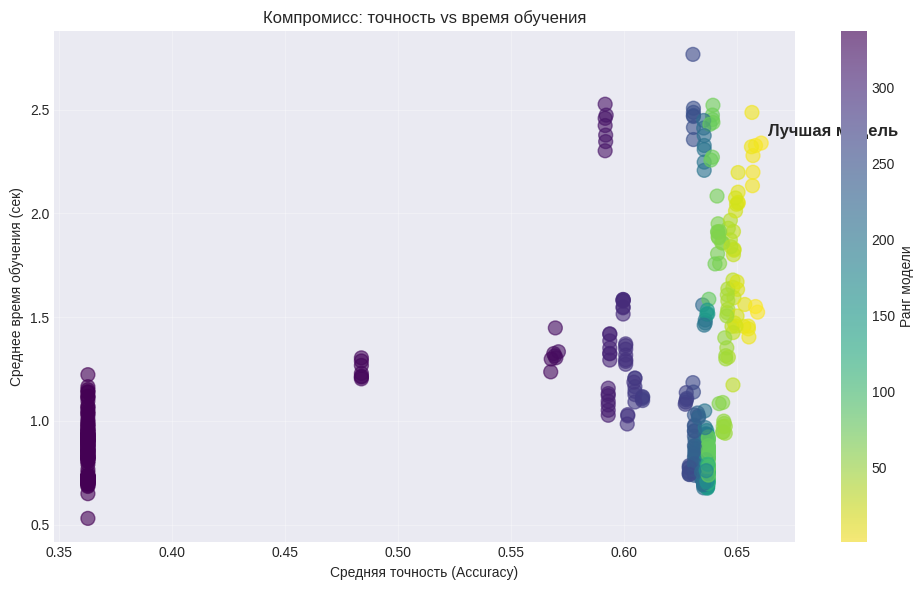

In [79]:
plot_complexity_and_accuracy(women_age_gs)

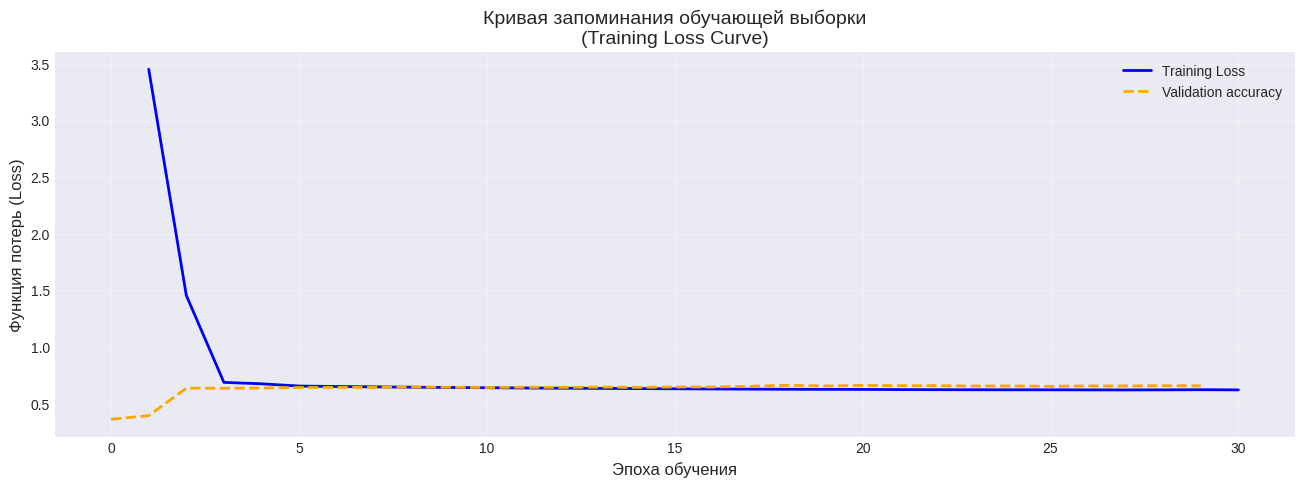

In [92]:
fig, axes = create_panel(1, cols=1)
loss_curve(women_age_gs.best_estimator_['model'], axes.flat[0])

In [80]:
women_age_best_model_params = {
    'model__activation': 'relu',
    'model__alpha': 1e-05,
    'model__early_stopping': True,
    'model__hidden_layer_sizes': (96, 64),
    'model__learning_rate_init': 0.0001,
    'model__max_iter': 500,
    'model__random_state': 42,
    'model__solver': 'adam',
    'model__validation_fraction': 0.2
}
women_age_best_model = create_mlp_pipeline()
women_age_best_model.set_params(**women_age_best_model_params)
women_age_best_model_iter_learning_score = iteration_learning_score(women_age_best_model, women_train, women_train['age'])

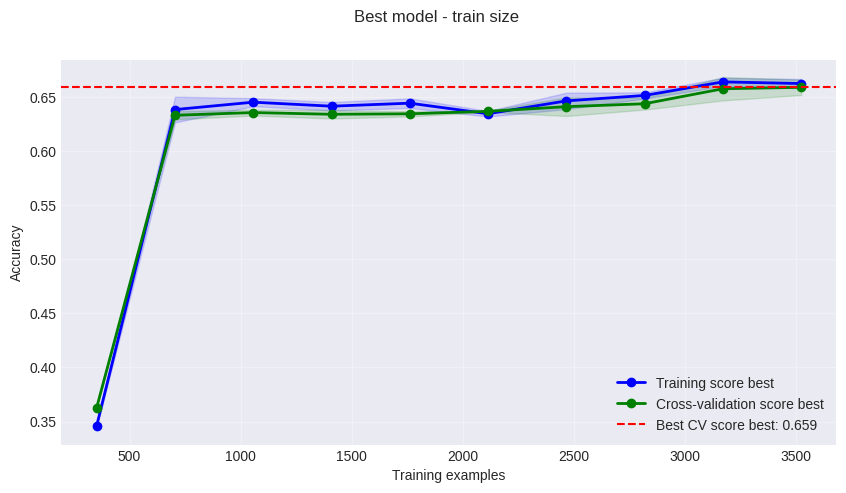

In [81]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*women_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plt.suptitle("Best model - train size")
plt.show()

Использование нейронных сетей повышает точность в каскадном подходе с 61.9% до 63.4-65.9% 

In [82]:
women_age_best_model.fit(women_train, women_train['age'])
save(
    women_age_best_model, 
    "mlp_women_age_best", 
    women_age_best_model_params, 
    { "val": women_age_best_model_iter_learning_score[2].tolist(), "train": women_age_best_model_iter_learning_score[1].tolist() }
)

## Плоский подход

In [83]:
flat_y_train = train['gender'] * 2 + train['age']

In [84]:
flat_pipeline = create_mlp_pipeline()

flat_gs = grid_search(flat_pipeline, pipeline_params, train, flat_y_train)

Fitting 5 folds for each of 462 candidates, totalling 2310 fits


In [85]:
flat_gs.best_params_, flat_gs.best_score_

({'model__activation': 'relu',
  'model__alpha': 0.05,
  'model__early_stopping': True,
  'model__hidden_layer_sizes': 128,
  'model__learning_rate_init': 0.0001,
  'model__max_iter': 500,
  'model__random_state': 42,
  'model__solver': 'adam',
  'model__validation_fraction': 0.2},
 np.float64(0.4461298701298701))

In [86]:
flat_top_5_info = get_top_n_info(flat_gs, n=5)
flat_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__activation,param_model__alpha,param_model__early_stopping,param_model__hidden_layer_sizes,param_model__learning_rate_init,param_model__max_iter,...,param_model__validation_fraction,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
275,4.823323,0.724401,0.027506,0.004318,relu,0.0500,True,128,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.440000,0.448312,0.444675,0.458182,0.439481,0.446130,0.006840,1
77,5.168068,0.644152,0.027539,0.004415,relu,0.0001,True,128,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.438961,0.450909,0.446234,0.460779,0.432208,0.445818,0.009820,2
71,5.883076,0.944507,0.033272,0.007135,relu,0.0001,True,"(198,)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.438961,0.448312,0.444156,0.446753,0.448312,0.445299,0.003514,3
335,6.067537,1.143578,0.037523,0.007773,relu,0.1000,True,"(198,)",0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.440519,0.445195,0.442078,0.446753,0.447273,0.444364,0.002641,4
143,4.392248,0.803248,0.028248,0.003179,relu,0.0010,True,128,0.0001,500,...,0.2,"{'model__activation': 'relu', 'model__alpha': ...",0.441039,0.438961,0.447792,0.455584,0.437922,0.444260,0.006623,5


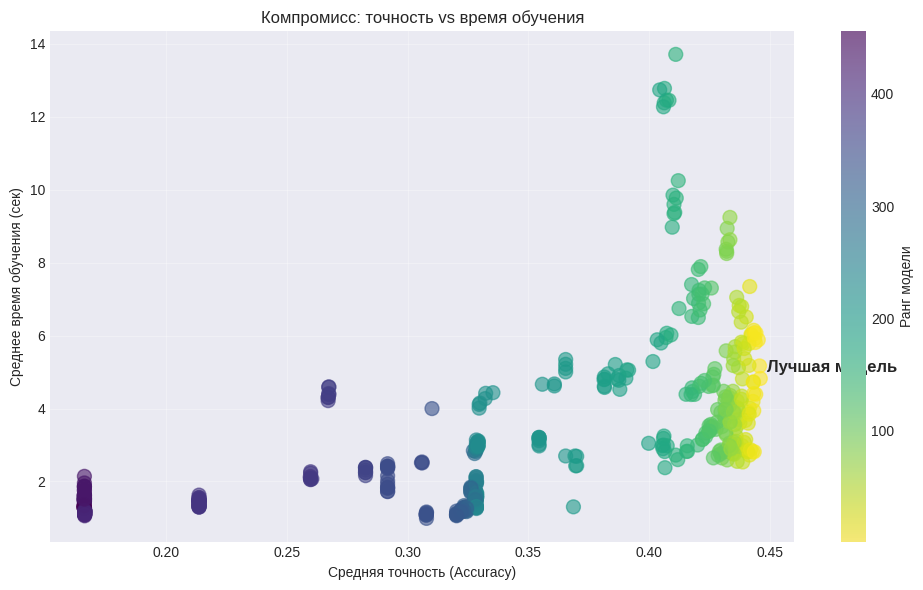

In [87]:
plot_complexity_and_accuracy(flat_gs)

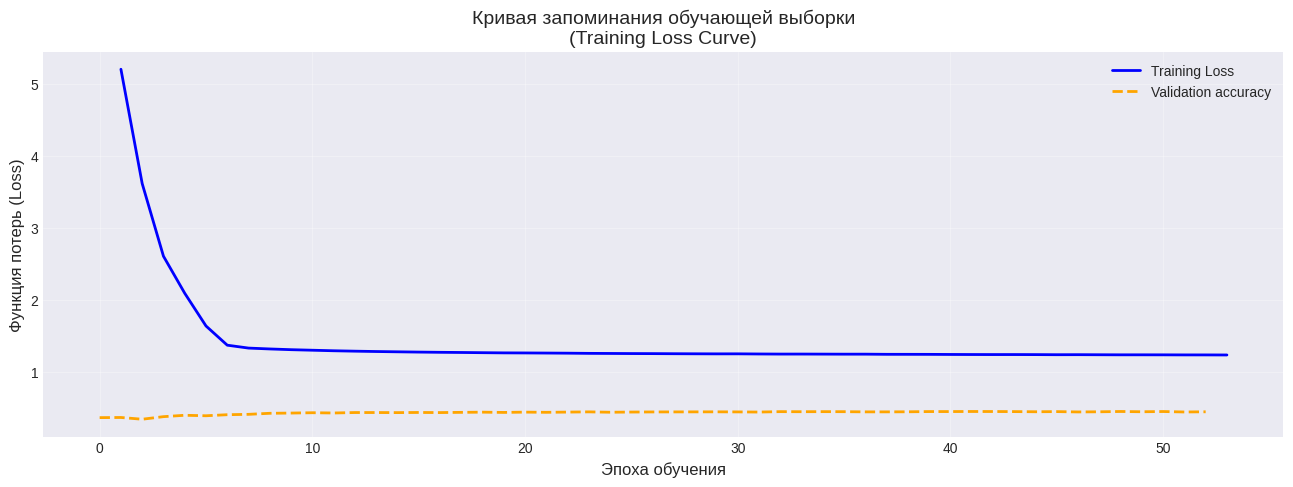

In [93]:
fig, axes = create_panel(1, cols=1)
loss_curve(flat_gs.best_estimator_['model'], axes.flat[0])

In [88]:
flat_best_model_params = {
    'model__activation': 'relu',
    'model__alpha': 0.05,
    'model__early_stopping': True,
    'model__hidden_layer_sizes': 128,
    'model__learning_rate_init': 0.0001,
    'model__max_iter': 500,
    'model__random_state': 42,
    'model__solver': 'adam',
    'model__validation_fraction': 0.2
}
flat_best_model = create_mlp_pipeline()
flat_best_model.set_params(**flat_best_model_params)
flat_best_model_iter_learning_score = iteration_learning_score(flat_best_model, train, flat_y_train)

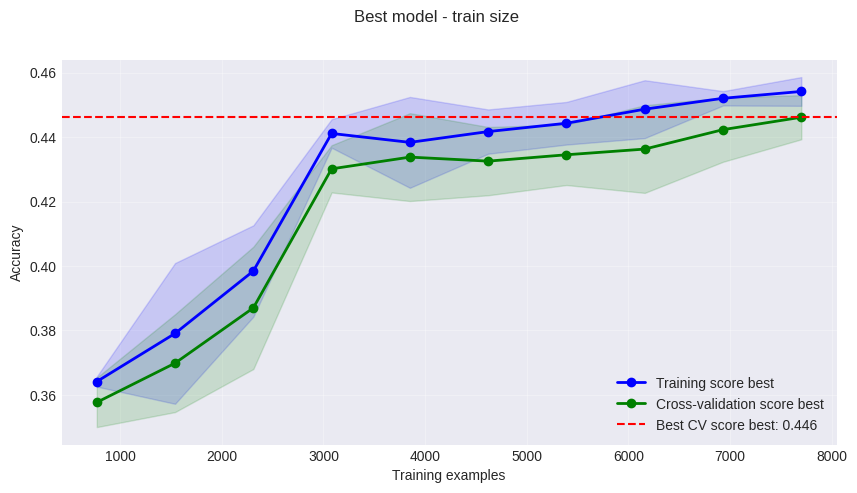

In [89]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*flat_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plt.suptitle("Best model - train size")
plt.show()

Точность каскадного подхода приблизительно составит `0.669 * 0.634 = 0.424`. Плоский подход показывает точность на 2% выше

In [90]:
flat_best_model.fit(train, flat_y_train)
save(
    flat_best_model, 
    "mlp_flat_best", 
    flat_best_model_params, 
    { "val": flat_best_model_iter_learning_score[2].tolist(), "train": flat_best_model_iter_learning_score[1].tolist() }
)